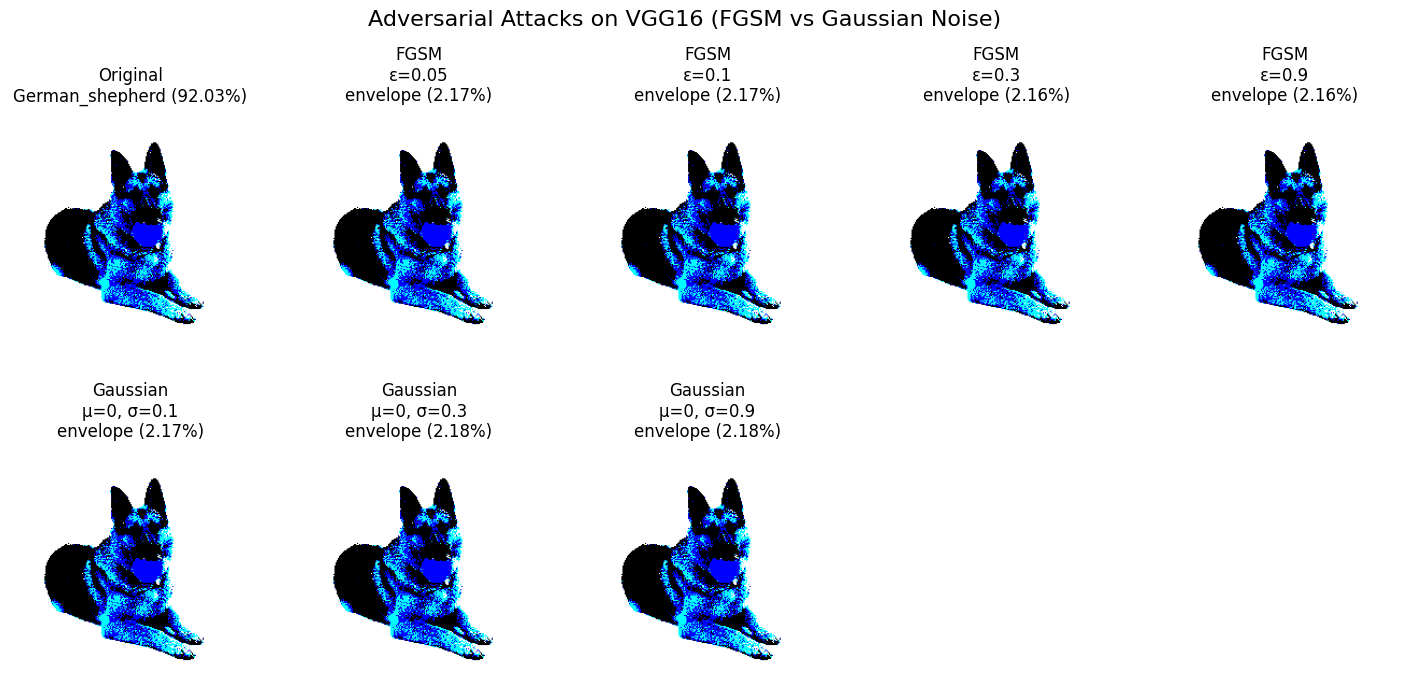

In [7]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16, vgg16
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model = VGG16(weights='imagenet')

# Load and preprocess input image
image_url = "https://www.warrenphotographic.co.uk/photography/bigs/24364-Alsatian-dog-holding-a-ball-white-background.jpg"
img_path = tf.keras.utils.get_file('german_shepard.jpg', image_url)
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = vgg16.preprocess_input(x)
x_tensor = tf.convert_to_tensor(x, dtype=tf.float32)

# Function to deprocess images for plotting
def deprocess(img):
    img = img.copy()
    img = img + 1.0
    img = img * 127.5
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

# FGSM attack
def fgsm_attack(model, x, y_true, epsilon):
    with tf.GradientTape() as tape:
        tape.watch(x)
        predictions = model(x)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, predictions)
    gradient = tape.gradient(loss, x)
    x_adv = x + epsilon * tf.sign(gradient)
    x_adv = tf.clip_by_value(x_adv, -1, 1)
    return x_adv

# Gaussian noise attack
def gaussian_attack(x, mean=0.0, std=0.05):
    noise = np.random.normal(loc=mean, scale=std, size=x.shape)
    x_noisy = x + noise
    x_noisy = np.clip(x_noisy, -1, 1)
    return x_noisy

# Original prediction
orig_pred = model(x_tensor)
orig_label = vgg16.decode_predictions(orig_pred.numpy())[0][0]

# FGSM epsilon values
epsilons = [0.05, 0.1, 0.3, 0.9]

# Gaussian noise standard deviations
gaussian_std = [0.1, 0.3, 0.9]


plt.figure(figsize=(18,8))

# Plot original image
plt.subplot(2, max(len(epsilons), len(gaussian_std)) + 1, 1)
plt.imshow(deprocess(x[0]))
plt.title(f"Original\n{orig_label[1]} ({orig_label[2]*100:.2f}%)")
plt.axis('off')

# FGSM attacks
y_true = tf.argmax(orig_pred, axis=1)  # use predicted label as "true"
for i, eps in enumerate(epsilons):
    x_adv = fgsm_attack(model, x_tensor, y_true, epsilon=eps)
    adv_pred = model(x_adv)
    adv_label = vgg16.decode_predictions(adv_pred.numpy())[0][0]
    plt.subplot(2, max(len(epsilons), len(gaussian_std)) + 1, i+2)
    plt.imshow(deprocess(x_adv.numpy()[0]))
    plt.title(f"FGSM\nε={eps}\n{adv_label[1]} ({adv_label[2]*100:.2f}%)")
    plt.axis('off')

# Gaussian attacks
for j, std in enumerate(gaussian_std):
    x_gauss = gaussian_attack(x, mean=0.0, std=std)
    adv_pred = model(x_gauss)
    adv_label = vgg16.decode_predictions(adv_pred.numpy())[0][0]
    plt.subplot(2, max(len(epsilons), len(gaussian_std)) + 1, j+2+len(epsilons))
    plt.imshow(deprocess(x_gauss[0]))
    plt.title(f"Gaussian\nμ=0, σ={std}\n{adv_label[1]} ({adv_label[2]*100:.2f}%)")
    plt.axis('off')

plt.suptitle("Adversarial Attacks on VGG16 (FGSM vs Gaussian Noise)", fontsize=16)
plt.show()